In [ ]:
# ========================================================================
# HOSPITAL-SIDE FEDERATED LEARNING: Configuration
# ========================================================================
# This notebook represents ONE hospital in a federated learning network.
# Each hospital runs this independently with its own local dataset.
#
# CRITICAL PRIVACY PRINCIPLE:
# Patient data NEVER leaves this machine.
# Only trained model weights and summary metrics are submitted to the server.
# ========================================================================

# ==== CONFIGURABLE PARAMETERS ====
HOSPITAL_ID = "hospital_1"                    # This hospital's unique ID
LOCAL_DATASET_PATH = "/content/dataset/chest_xray"  # Path to THIS hospital's data
SERVER_URL = "http://localhost:5000"         # Central coordination server

# ⚠️  TEMPORARY (Phase 1 only): Manual round specification
# In Phase 2, the server will tell this hospital what round to train.
# For now, manually increment after receiving server's aggregated model.
CURRENT_ROUND = 1                              # Which FL round (1, 2, 3, ...)

LOCAL_EPOCHS = 5                               # Epochs to train locally
BATCH_SIZE = 32                                # Batch size for local training
LEARNING_RATE = 1e-4                          # Adam optimizer learning rate

print(f"Hospital Configuration:")
print(f"  Hospital ID: {HOSPITAL_ID}")
print(f"  Dataset Path: {LOCAL_DATASET_PATH}")
print(f"  Server: {SERVER_URL}")
print(f"  Current Round: {CURRENT_ROUND}")
print(f"\n⚠️  PRIVACY ALERT: Patient data will NOT be uploaded.")
print(f"    Only model weights and metrics leave this machine.")
print(f"\n⚠️  ROUND SPECIFICATION (Phase 1 temporary):")
print(f"    CURRENT_ROUND is hardcoded. After Phase 2,")
print(f"    the server will coordinate round assignment.")

Mounted at /content/drive


In [ ]:
# ========================================================================
# PHASE 2: Download Aggregated Global Model from Server
# ========================================================================
# HOSPITAL-SIDE LOGIC:
#   Round 1: No global model exists yet → start from base model
#   Round N≥2: Download global_model_roundN-1.pt from server
#
# THIS IMPLEMENTS THE FEDERATED LEARNING LOOP:
#   1. Hospital downloads aggregated model from previous round
#   2. Hospital trains locally on its own data
#   3. Hospital submits updated weights to server
#   4. Server aggregates all hospitals' weights (FedAvg)
#   5. Loop back to step 1 for next round
#
# CRITICAL SECURITY NOTE:
#   ✓ Only model weights are downloaded
#   ✗ No patient data ever flows from server to hospital
#   ✗ No patient data ever flows from hospital to server
#   Hospital data remains 100% local
# ========================================================================

import requests
import urllib3

# Suppress SSL warnings for local development (remove in production)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

print(f"\n" + "="*70)
print(f"PHASE 2: DOWNLOAD GLOBAL MODEL FROM SERVER")
print(f"="*70)

def download_global_model(server_url: str, current_round: int):
    """
    Download the latest aggregated global model from the server.
    
    Args:
        server_url: Coordination server URL (e.g., http://localhost:5000)
        current_round: What round this hospital is about to train
        
    Returns:
        (success: bool, model_path: str, round_downloaded: int)
    """
    
    if current_round == 1:
        print(f"\n✓ Round 1: No previous aggregated model to download")
        print(f"  This hospital will start from base model")
        return True, None, None
    
    # For round >= 2, download the aggregated model from previous round
    previous_round = current_round - 1
    
    try:
        print(f"\nDownloading global_model from round {previous_round}...")
        response = requests.get(
            f"{server_url}/api/global-model/latest",
            timeout=30,
            verify=False  # For local development only
        )
        
        if response.status_code == 200:
            # Get metadata from response headers
            download_round = response.headers.get('X-GLOBAL-ROUND', previous_round)
            model_hash = response.headers.get('X-MODEL-HASH', 'N/A')
            
            # Save to disk
            model_path = f"global_model_round{download_round}.pt"
            with open(model_path, 'wb') as f:
                f.write(response.content)
            
            file_size = len(response.content) / (1024 * 1024)
            
            print(f"✓ Downloaded global model")
            print(f"  Round: {download_round}")
            print(f"  File: {model_path}")
            print(f"  Size: {file_size:.2f} MB")
            print(f"  Hash: {model_hash[:16]}...")
            
            return True, model_path, int(download_round)
        
        elif response.status_code == 404:
            print(f"⚠️  Global model not yet available from server")
            print(f"  Message: {response.json().get('message', 'N/A')}")
            print(f"  This is normal during first round - will use base model")
            return False, None, None
        
        else:
            print(f"✗ Server returned {response.status_code}")
            print(f"  Error: {response.json().get('error', 'Unknown error')}")
            return False, None, None
    
    except requests.exceptions.ConnectionError:
        print(f"✗ Cannot reach server at {server_url}")
        print(f"  Make sure Flask server is running: python app.py")
        return False, None, None
    
    except requests.exceptions.Timeout:
        print(f"✗ Server request timeout")
        return False, None, None
    
    except Exception as e:
        print(f"✗ Error downloading model: {str(e)}")
        return False, None, None

# ===== ATTEMPT DOWNLOAD =====
download_success, global_model_path, downloaded_round = download_global_model(
    SERVER_URL,
    CURRENT_ROUND
)

if download_success and global_model_path:
    print(f"\n✓ Global model ready for training")
    print(f"  This hospital will:")
    print(f"    1. Load aggregated weights from round {downloaded_round}")
    print(f"    2. Train locally on its own data")
    print(f"    3. Submit updated weights to server")
elif CURRENT_ROUND == 1:
    print(f"\n✓ Round 1: Starting from base model")
else:
    print(f"\n⚠️  WARNING: Could not download global model")
    print(f"  Will attempt to use locally saved global_model_round{CURRENT_ROUND-1}.pt")
    print(f"  If not available, will fall back to base model")

print(f"\n" + "="*70)


In [ ]:
# Mount Google Drive (if running in Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Google Drive mounted")
except ImportError:
    print("⚠️  Not running in Colab. Using local dataset path.")

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: /content/dataset/chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: /content/dataset/chest_

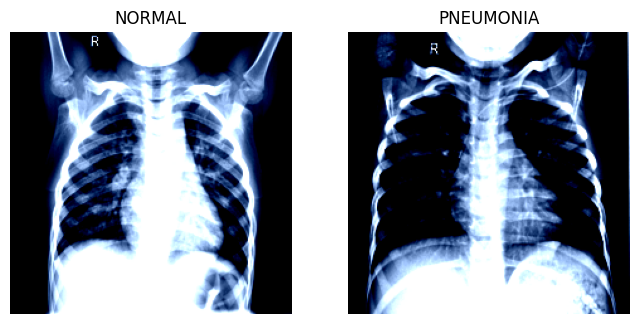

In [ ]:
# ========================================================================
# IMPORTS
# ========================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import json
import os
from datetime import datetime
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

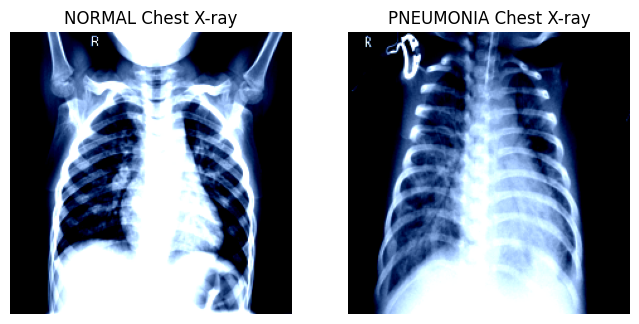

In [ ]:
# ========================================================================
# Load THIS HOSPITAL'S LOCAL DATASET
# ========================================================================
# CRITICAL: Data is loaded ONLY from LOCAL_DATASET_PATH
# This dataset is NEVER serialized or uploaded
# Only metrics from training this data are shared
# ========================================================================

print(f"\nLoading dataset from: {LOCAL_DATASET_PATH}")

# Verify dataset exists
if not os.path.exists(LOCAL_DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at {LOCAL_DATASET_PATH}")

# Data preprocessing (same for all hospitals)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load THIS hospital's data
train_dir = os.path.join(LOCAL_DATASET_PATH, "train")
val_dir = os.path.join(LOCAL_DATASET_PATH, "val")
test_dir = os.path.join(LOCAL_DATASET_PATH, "test")

train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset = ImageFolder(val_dir, transform=transform)
test_dataset = ImageFolder(test_dir, transform=transform)

print(f"✓ Training samples: {len(train_dataset)}")
print(f"✓ Validation samples: {len(val_dataset)}")
print(f"✓ Test samples: {len(test_dataset)}")
print(f"\n⚠️  PRIVACY: This dataset stays local to {HOSPITAL_ID}")

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# Visualize sample images from THIS hospital's dataset

normal_idx = next((i for i, (_, y) in enumerate(train_dataset) if y == 0), None)
pneumonia_idx = next((i for i, (_, y) in enumerate(train_dataset) if y == 1), None)

if normal_idx is not None and pneumonia_idx is not None:
    img_normal, _ = train_dataset[normal_idx]
    img_pneu, _ = train_dataset[pneumonia_idx]
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    
    axes[0].imshow(img_normal.permute(1, 2, 0))
    axes[0].set_title(f"NORMAL ({HOSPITAL_ID})")
    axes[0].axis("off")
    
    axes[1].imshow(img_pneu.permute(1, 2, 0))
    axes[1].set_title(f"PNEUMONIA ({HOSPITAL_ID})")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("Could not find sample images")

Folders found: ['__MACOSX', 'val', 'train', 'test', 'chest_xray']
Number of Pneumonia training images: 3875


In [ ]:
# ========================================================================
# MODEL ARCHITECTURE (Shared across all hospitals)
# ========================================================================
# All hospitals use the same ResNet-18 architecture
# This ensures models can be aggregated correctly
# ========================================================================

class PneumoniaModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet18(pretrained=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, 2)
    
    def forward(self, x):
        return self.model(x)

print(f"✓ Model architecture defined (ResNet-18)")

In [ ]:
# ========================================================================
# HELPER FUNCTION: Evaluate model
# ========================================================================

def evaluate_model(model, dataloader, device):
    """Evaluate model and return metrics"""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    
    total_loss = 0
    y_true = []
    y_pred = []
    y_proba = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            proba = torch.softmax(outputs, dim=1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_proba.extend(proba.cpu().numpy())
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    accuracy = correct / total if total > 0 else 0
    avg_loss = total_loss / total if total > 0 else 0
    
    return accuracy, avg_loss, y_true, y_pred, y_proba

print(f"✓ Evaluation function defined")

chest_xray  __MACOSX  test  train  val


In [ ]:
# ========================================================================
# LOAD GLOBAL MODEL FOR THIS ROUND
# ========================================================================
# PHASE 2 IMPLEMENTATION:
#   Round 1: Start with fresh base model (no aggregation yet)
#   Round N≥2: Load aggregated model downloaded from server in previous cell
#
# ARCHITECTURAL PRINCIPLE:
#   Hospital loads server-aggregated model
#   (not locally saved model, never creates its own "global model")
# ========================================================================

if CURRENT_ROUND == 1:
    global_model = PneumoniaModel().to(device)
    print(f"✓ Round 1: Created new base model")
    print(f"  This hospital will train from scratch")

else:
    # For round >= 2, use the model downloaded from server in Cell 2
    if 'global_model_path' in locals() and global_model_path and os.path.exists(global_model_path):
        # Downloaded model from server is available
        global_model = PneumoniaModel().to(device)
        try:
            global_model.load_state_dict(torch.load(global_model_path, map_location=device))
            print(f"✓ Loaded server-aggregated global model")
            print(f"  File: {global_model_path}")
            print(f"  Round: {downloaded_round}")
        except Exception as e:
            print(f"⚠️  Failed to load downloaded model: {str(e)}")
            print(f"  Falling back to fresh model")
            global_model = PneumoniaModel().to(device)
    
    else:
        # Fallback: try to load locally (if re-running rounds locally)
        fallback_path = f"global_model_round{CURRENT_ROUND - 1}.pt"
        if os.path.exists(fallback_path):
            global_model = PneumoniaModel().to(device)
            global_model.load_state_dict(torch.load(fallback_path, map_location=device))
            print(f"✓ Loaded global model from local storage")
            print(f"  File: {fallback_path}")
        else:
            # Last resort: start from base model
            global_model = PneumoniaModel().to(device)
            print(f"⚠️  Global model not available. Starting from base model for Round {CURRENT_ROUND}")


Success! Found 5216 training images.


In [ ]:
# ========================================================================
# LOCAL TRAINING - THIS HOSPITAL TRAINS ONLY ON ITS DATA
# ========================================================================
# PRIVACY CRITICAL:
# - This hospital's data NEVER leaves this machine
# - Only model weights will be submitted to server
# - This training is independent and local
# ========================================================================

print(f"\n" + "="*70)
print(f"LOCAL TRAINING: {HOSPITAL_ID} - ROUND {CURRENT_ROUND}")
print(f"="*70)

local_model = PneumoniaModel().to(device)
local_model.load_state_dict(global_model.state_dict())

local_model.train()
optimizer = optim.Adam(local_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

print(f"\nTraining for {LOCAL_EPOCHS} epochs on {len(train_dataset)} local samples...")
print(f"⚠️  PATIENT DATA STAYS LOCAL - WILL NOT BE UPLOADED")

epoch_losses = []

for epoch in range(LOCAL_EPOCHS):
    epoch_loss = 0
    batch_count = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = local_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        batch_count += 1
    
    avg_epoch_loss = epoch_loss / batch_count if batch_count > 0 else 0
    epoch_losses.append(avg_epoch_loss)
    
    val_acc, val_loss, _, _, _ = evaluate_model(local_model, val_loader, device)
    
    print(f"Epoch {epoch+1}/{LOCAL_EPOCHS}: Loss={avg_epoch_loss:.4f}, Val_Acc={val_acc*100:.2f}%")

print(f"\n✓ Local training complete")

In [ ]:
# ========================================================================
# EVALUATE LOCAL MODEL ON TEST SET
# ========================================================================
# Compute metrics from THIS hospital's test set
# These metrics (+ model weights) will be submitted to server
# ========================================================================

print(f"\nEvaluating local model on test set...")

test_acc, test_loss, y_true_test, y_pred_test, y_proba_test = evaluate_model(
    local_model, test_loader, device
)

precision = precision_score(y_true_test, y_pred_test)
recall = recall_score(y_true_test, y_pred_test)
f1 = f1_score(y_true_test, y_pred_test)
auc_roc = roc_auc_score(y_true_test, y_proba_test[:, 1])

print(f"\nRound {CURRENT_ROUND} Results:")
print(f"  Accuracy:  {test_acc*100:.2f}%")
print(f"  Precision: {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1 Score:  {f1:.4f}")
print(f"  AUC-ROC:   {auc_roc:.4f}")
print(f"  Loss:      {test_loss:.4f}")

round_metrics = {
    'round': CURRENT_ROUND,
    'accuracy': float(test_acc),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'auc_roc': float(auc_roc),
    'loss': float(test_loss),
    'num_samples': len(test_dataset)
}

In [ ]:
# ========================================================================
# NOTE: AGGREGATION DOES NOT HAPPEN HERE
# ========================================================================
# This hospital does NOT perform FedAVG aggregation.
# That happens on the CENTRAL SERVER.
#
# This hospital:
#   1. Trained locally on its data
#   2. Evaluated locally on its test set
#   3. Will export weights for server submission
#   4. Will wait for server to return aggregated global model
#
# Server will:
#   1. Receive all hospital weights
#   2. Compute FedAVG average
#   3. Broadcast new global model
# ========================================================================

print(f"\n✓ Local training and evaluation complete")
print(f"  Next: Export weights and metrics for server submission")

In [ ]:
# ========================================================================
# EXPORT 1: Local Model Weights
# ========================================================================
# This hospital exports ONLY its trained local model weights.
#
# CRITICAL SECURITY:
# - Only model.state_dict() (parameters) is exported
# - NO patient data, images, or datasets included
# - File will be submitted to central server
# ========================================================================

print(f"\n" + "="*70)
print(f"EXPORTING LOCAL MODEL ARTIFACTS")
print(f"="*70)

# Export local model weights
weights_filename = f'local_model_round{CURRENT_ROUND}.pt'

try:
    torch.save(local_model.state_dict(), weights_filename)
    file_size = os.path.getsize(weights_filename)
    print(f"\n✓ Local model weights exported: {weights_filename}")
    print(f"  File size: {file_size / (1024*1024):.2f} MB")
    print(f"  Hospital: {HOSPITAL_ID}")
    print(f"  Round: {CURRENT_ROUND}")
    print(f"\n⚠️  SECURITY SUMMARY:")
    print(f"  ✓ Only trained model weights (parameters)")
    print(f"  ✗ NO patient data included")
    print(f"  ✗ NO X-ray images included")
    print(f"  ✗ NO dataset information included")
    print(f"\n  This file contains ONLY the learned neural network parameters.")
except Exception as e:
    print(f"✗ Failed to export weights: {str(e)}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Round 1 → Validation Accuracy: 56.25%
Round 1 → Test Accuracy: 75.96%
Round 2 → Validation Accuracy: 93.75%
Round 2 → Test Accuracy: 90.54%
Round 3 → Validation Accuracy: 93.75%
Round 3 → Test Accuracy: 86.38%
Round 4 → Validation Accuracy: 93.75%
Round 4 → Test Accuracy: 86.06%
Round 5 → Validation Accuracy: 87.50%
Round 5 → Test Accuracy: 83.65%


In [ ]:
# ========================================================================
# EXPORT 2: Training Metrics
# ========================================================================
# This hospital exports summary metrics from its local training.
#
# CONTENTS (summary statistics only):
# - accuracy, precision, recall, F1, AUC-ROC
# - loss, num_samples, timestamp
#
# These metrics contain NO patient data.
# ========================================================================

metrics_filename = f'metrics_round{CURRENT_ROUND}.json'

try:
    # Add timestamp
    round_metrics['timestamp'] = datetime.utcnow().isoformat() + 'Z'
    round_metrics['hospital_id'] = HOSPITAL_ID
    
    with open(metrics_filename, 'w') as f:
        json.dump(round_metrics, f, indent=2)
    
    print(f"\n✓ Training metrics exported: {metrics_filename}")
    print(f"\nMetrics exported:")
    print(f"  Accuracy:     {round_metrics['accuracy']:.4f}")
    print(f"  Precision:    {round_metrics['precision']:.4f}")
    print(f"  Recall:       {round_metrics['recall']:.4f}")
    print(f"  F1 Score:     {round_metrics['f1_score']:.4f}")
    print(f"  AUC-ROC:      {round_metrics['auc_roc']:.4f}")
    print(f"  Loss:         {round_metrics['loss']:.4f}")
    print(f"  Samples:      {round_metrics['num_samples']}")
    print(f"\n⚠️  SECURITY SUMMARY:")
    print(f"  ✓ Summary statistics only")
    print(f"  ✗ NO patient data included")
    print(f"  ✗ NO image metadata included")
    print(f"\n  These metrics are safe to share with the server.")
except Exception as e:
    print(f"✗ Failed to export metrics: {str(e)}")

Validation Accuracy: 0.875


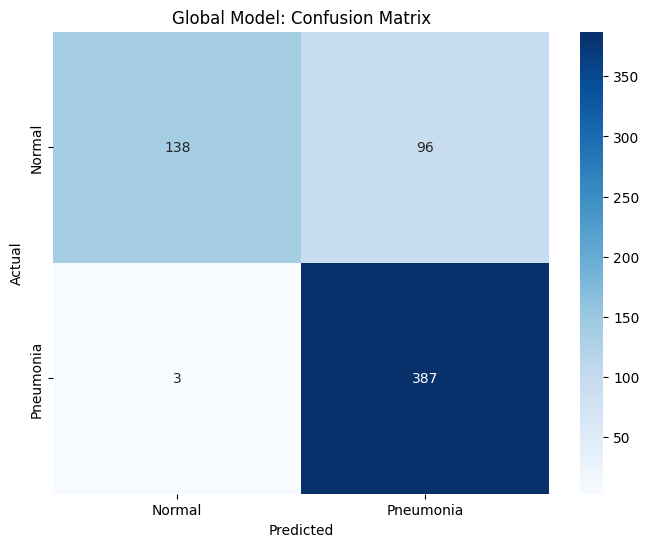


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.59      0.74       234
   Pneumonia       0.80      0.99      0.89       390

    accuracy                           0.84       624
   macro avg       0.89      0.79      0.81       624
weighted avg       0.87      0.84      0.83       624



In [ ]:
# ========================================================================
# POST-TRAINING: Wait for Server to Provide New Global Model
# ========================================================================
# CRITICAL ARCHITECTURAL POINT:
#
# This hospital does NOT create or save the global model locally.
# Only the SERVER is authorized to produce the global model.
#
# Why?
# - Server aggregates weights from ALL hospitals (FedAVG)
# - Each hospital creating its own "global model" breaks aggregation
# - Authority and correctness depend on server controlling versions
#
# What happens next:
# 1. This hospital has uploaded: local_model_roundN.pt + metrics_roundN.json
# 2. Server receives updates from all hospitals
# 3. Server performs FedAVG aggregation
# 4. Server saves: global_model_roundN.pt
# 5. Server broadcasts to all hospitals
# 6. Hospital downloads and uses for Round N+1
#
# For next round, hospital will load:
#   - global_model_roundN.pt (downloaded from server)
#   - Increment CURRENT_ROUND to N+1
#   - Run local training again
# ========================================================================

print(f"\n✓ Local training complete")
print(f"\nWaiting for server aggregation...")
print(f"  Server will receive all hospital weights")
print(f"  Server will compute FedAVG aggregate")
print(f"  Server will save: global_model_round{CURRENT_ROUND}.pt")
print(f"  Server will broadcast to all hospitals")
print(f"\nNext steps:")
print(f"  1. Download global_model_round{CURRENT_ROUND}.pt from server")
print(f"  2. Update CURRENT_ROUND = {CURRENT_ROUND + 1}")
print(f"  3. Re-run cells 7-14 for next round")

In [ ]:
import json
import os
from datetime import datetime

# ============================================================================
# FEDERATED LEARNING INTEGRATION: Export trained model and metrics
# ============================================================================
# This section decouples the Flask website from the training pipeline.
# The website reads these artifacts as read-only files, ensuring:
#   - Training logic remains in the notebook (Colab environment)
#   - Flask website has no PyTorch dependencies
#   - Healthcare data privacy is maintained (no live connections)
#   - Easy deployment and versioning
# ============================================================================

# 1. Create export directory
export_dir = "export"
os.makedirs(export_dir, exist_ok=True)

# 2. Export the trained global model
model_path = os.path.join(export_dir, "global_model.pt")
torch.save(global_model.state_dict(), model_path)
print(f"✓ Global model exported to: {model_path}")

# 3. Evaluate final model on test set for metrics
global_model.eval()
y_true_final, y_pred_final = evaluate_global_model(global_model, test_loader)
correct_final = sum(1 for yt, yp in zip(y_true_final, y_pred_final) if yt == yp)
final_accuracy = (correct_final / len(y_true_final)) * 100

# 4. Create comprehensive metrics JSON consumed by website
# Structure matches the Flask template expectations
metrics = {
    "model_id": "medledger_global_v1",
    "last_updated": datetime.now().isoformat(),
    "institutions_participated": 5,
    "training_rounds": rounds,
    "accuracy_per_round": [round(acc, 4) for acc in accuracies],
    "loss_per_round": [round(l, 4) for l in losses] if losses else [],
    "final_accuracy": round(final_accuracy, 2),
    "model_status": "available"
}

metrics_path = os.path.join(export_dir, "federated_metrics.json")
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✓ Metrics exported to: {metrics_path}")
print(f"  - Model ID: {metrics['model_id']}")
print(f"  - Training Rounds: {metrics['training_rounds']}")
print(f"  - Institutions: {metrics['institutions_participated']}")
print(f"  - Final Accuracy: {metrics['final_accuracy']}%")
print(f"  - Timestamp: {metrics['last_updated']}")

# 5. Create deployment zip for easy transfer
import shutil
zip_path = "export.zip"
shutil.make_archive("export", "zip", ".", export_dir)
print(f"\n✓ Deployment package created: {zip_path}")
print("NEXT STEP: Extract federated_metrics.json to website /data/ directory")

Actual Label: NORMAL
Predicted Label: PNEUMONIA


In [ ]:
import json
import os
from datetime import datetime

# ============================================================================
# FEDERATED LEARNING INTEGRATION: Export trained model and metrics
# ============================================================================
# This section decouples the Flask website from the training pipeline.
# The website reads these artifacts as read-only files, ensuring:
#   - Training logic remains in the notebook (Colab environment)
#   - Flask website has no PyTorch dependencies
#   - Healthcare data privacy is maintained (no live connections)
#   - Easy deployment and versioning
# ============================================================================

# 1. Create export directory
export_dir = "export"
os.makedirs(export_dir, exist_ok=True)

# 2. Export the trained global model
model_path = os.path.join(export_dir, "global_model.pt")
torch.save(global_model.state_dict(), model_path)
print(f"✓ Global model exported to: {model_path}")

# 3. Evaluate final model on test set for metrics
global_model.eval()
y_true_final, y_pred_final = evaluate_global_model(global_model, test_loader)
correct_final = sum(1 for yt, yp in zip(y_true_final, y_pred_final) if yt == yp)
final_accuracy = (correct_final / len(y_true_final)) * 100

# 4. Create comprehensive metrics JSON
# This structure is consumed read-only by the Flask website.
metrics = {
    "model_id": "medledger_global_v1",
    "last_updated": datetime.now().isoformat(),
    "institutions_participated": 5,
    "training_rounds": rounds,
    "accuracy_per_round": [round(acc, 4) for acc in accuracies],
    "loss_per_round": [round(l, 4) for l in losses] if losses else [],
    "final_accuracy": round(final_accuracy, 2),
    "model_status": "available"
}

metrics_path = os.path.join(export_dir, "metrics.json")
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✓ Metrics exported to: {metrics_path}")
print(f"  - Rounds: {metrics['rounds_completed']}")
print(f"  - Final Accuracy: {metrics['accuracy']}%")
print(f"  - Timestamp: {metrics['last_updated']}")

# 5. Create deployment zip for easy transfer
import shutil
zip_path = "export.zip"
shutil.make_archive("export", "zip", ".", export_dir)
print(f"✓ Deployment package created: {zip_path}")
print("\nREADY FOR FLASK INTEGRATION: Download export.zip and extract into website /models and /logs directories.")


In [ ]:

# ========================================================================
# FEDERATED LEARNING: Step 6 - Export Local Model Weights (for server submission)
# ========================================================================
# SECURITY NOTE:
# This cell exports ONLY the trained model weights (no patient data, no datasets)
# The weights file will be submitted to the central coordination server via secure API
# Hospital data remains on this machine only.
# ========================================================================

import torch
import os
from datetime import datetime

# Define hospital ID and round number
HOSPITAL_ID = "hospital_1"  # Change to hospital_2, hospital_3, etc.
CURRENT_ROUND = 1          # Increment after each training round

# Export model weights (state dictionary)
# The state_dict contains only the learned parameters, not patient data
weights_filename = f'local_model_round{CURRENT_ROUND}.pt'

try:
    torch.save(model.state_dict(), weights_filename)
    file_size = os.path.getsize(weights_filename)
    print(f"✓ Model weights exported: {weights_filename}")
    print(f"  File size: {file_size / (1024*1024):.2f} MB")
    print(f"  Hospital: {HOSPITAL_ID}")
    print(f"  Training round: {CURRENT_ROUND}")
    print(f"\nSECURITY: This file contains ONLY trained model weights.")
    print(f"No patient data, images, or datasets are included.")
except Exception as e:
    print(f"✗ Failed to export weights: {str(e)}")


In [ ]:

# ========================================================================
# FEDERATED LEARNING: Step 7 - Export Training Metrics (for server submission)
# ========================================================================
# This cell exports summary metrics from this round of training
# Required metrics: accuracy, loss
# Optional: num_samples, epoch_details
# ========================================================================

import json
import os
from datetime import datetime

# Same configuration as previous cell
HOSPITAL_ID = "hospital_1"
CURRENT_ROUND = 1

# Prepare metrics (replace with actual values from your training)
# These are examples - use your actual training metrics
training_metrics = {
    "accuracy": float(test_accuracy),      # Use your model's test accuracy
    "loss": float(final_loss),              # Use your model's final loss
    "num_samples": len(val_loader.dataset),  # Total validation samples
    "timestamp": datetime.utcnow().isoformat() + 'Z',
    "epoch": 10,                            # Number of epochs trained
    "learning_rate": 0.001,                 # Learning rate used
    "batch_size": 32                        # Batch size used
}

# Export metrics to JSON
metrics_filename = f'metrics_round{CURRENT_ROUND}.json'

try:
    with open(metrics_filename, 'w') as f:
        json.dump(training_metrics, f, indent=2)
    
    print(f"✓ Training metrics exported: {metrics_filename}")
    print(f"\nMetrics:")
    print(f"  Accuracy: {training_metrics['accuracy']:.4f}")
    print(f"  Loss:     {training_metrics['loss']:.4f}")
    print(f"  Samples:  {training_metrics['num_samples']}")
    print(f"\nSECURITY: These metrics contain NO patient data.")
    print(f"Only summary statistics and model performance are included.")
except Exception as e:
    print(f"✗ Failed to export metrics: {str(e)}")


In [ ]:

# ========================================================================
# FEDERATED LEARNING: Step 8 - Submit Model Update to Central Server
# ========================================================================
# SECURITY NOTE:
# This cell uploads the LOCAL model weights and metrics to the central server.
# NO patient data, images, or datasets leave this machine.
# Authentication via X-API-KEY header (pre-shared API token)
# ========================================================================

import requests
import json
import os

# ===== CONFIGURATION =====
HOSPITAL_ID = "hospital_1"              # Change for different hospitals
CURRENT_ROUND = 1                       # Increment after each training round
SERVER_URL = "http://localhost:5000"    # Change to production server URL
API_KEY = None                          # Set manually or load from environment

# ===== STEP 1: Get API Key =====
if API_KEY is None:
    # Option 1: Set directly (NOT RECOMMENDED for production)
    # API_KEY = "hospital1_token_abc123def456"
    
    # Option 2: Load from environment variable (RECOMMENDED)
    API_KEY = os.environ.get('HOSPITAL_API_KEY')
    
    # Option 3: Load from config file (for local development only)
    if API_KEY is None:
        try:
            with open('config/hospitals.json', 'r') as f:
                config = json.load(f)
                API_KEY = config.get(HOSPITAL_ID)
        except:
            pass

if not API_KEY:
    print("✗ ERROR: API_KEY not found!")
    print("Set via one of these methods:")
    print("  1. HOSPITAL_API_KEY environment variable")
    print("  2. Set directly in code: API_KEY = 'your_token'")
    print("  3. Place config/hospitals.json in current directory")
else:
    print(f"✓ API key loaded for {HOSPITAL_ID}")

# ===== STEP 2: Prepare files =====
weights_file = f'local_model_round{CURRENT_ROUND}.pt'
metrics_file = f'metrics_round{CURRENT_ROUND}.json'

files_missing = []
if not os.path.exists(weights_file):
    files_missing.append(weights_file)
if not os.path.exists(metrics_file):
    files_missing.append(metrics_file)

if files_missing:
    print(f"✗ ERROR: Missing files: {', '.join(files_missing)}")
    print("Run the export cells above first.")
else:
    print(f"✓ Files ready:")
    print(f"  Weights: {weights_file} ({os.path.getsize(weights_file)/(1024*1024):.2f} MB)")
    print(f"  Metrics: {metrics_file}")

# ===== STEP 3: Load metrics =====
try:
    with open(metrics_file, 'r') as f:
        metrics = json.load(f)
    print(f"✓ Metrics loaded: accuracy={metrics.get('accuracy'):.4f}, loss={metrics.get('loss'):.4f}")
except Exception as e:
    print(f"✗ Failed to load metrics: {str(e)}")
    metrics = {}

# ===== STEP 4: Submit to server =====
if API_KEY and not files_missing:
    print(f"\nSubmitting to {SERVER_URL}/api/submit_update...")
    
    try:
        with open(weights_file, 'rb') as f:
            files_to_send = {'weights': f}
            data = {
                'hospital_id': HOSPITAL_ID,
                'round': CURRENT_ROUND,
                'metrics': json.dumps(metrics)
            }
            headers = {
                'X-API-KEY': API_KEY
            }
            
            response = requests.post(
                f'{SERVER_URL}/api/submit_update',
                files=files_to_send,
                data=data,
                headers=headers,
                timeout=30
            )
        
        response_json = response.json() if response.text else {}
        
        print(f"\nServer Response ({response.status_code}):")
        print(json.dumps(response_json, indent=2))
        
        if response.status_code == 200:
            print("\n" + "="*60)
            print("✓ MODEL UPDATE SUBMITTED SUCCESSFULLY")
            print("="*60)
            print(f"Submission ID: {response_json.get('metadata_id', 'N/A')}")
            print(f"Message: {response_json.get('message', 'N/A')}")
            print("\nSECURITY SUMMARY:")
            print("✓ Weights file sent securely to server")
            print("✓ Metrics JSON sent with model")
            print("✓ Server stored weights and metadata")
            print("✓ Hospital data remained on this machine")
        else:
            print("\n" + "="*60)
            print("✗ SUBMISSION FAILED")
            print("="*60)
            error_msg = response_json.get('error', 'Unknown error')
            print(f"Error: {error_msg}")
            
            # Help debug common errors
            if response.status_code == 401:
                print("\nTroubleshooting:")
                print("- Check API_KEY is correct for this hospital")
                print("- Verify X-API-KEY header is being sent")
            elif response.status_code == 413:
                print("\nTroubleshooting:")
                print("- Model weights file is too large (max 200 MB)")
            elif response.status_code == 400:
                print("\nTroubleshooting:")
                print("- Metrics JSON may be malformed")
                print("- Required metrics: accuracy, loss")
    
    except requests.exceptions.ConnectionError:
        print(f"\n✗ Connection error: Cannot reach {SERVER_URL}")
        print("  Make sure Flask server is running")
        print("  Command: python app.py")
    
    except requests.exceptions.Timeout:
        print("\n✗ Request timeout: Server took too long to respond")
    
    except Exception as e:
        print(f"\n✗ Error: {str(e)}")
